In [1]:
# <finetuning_cleaned.py>

import os
import sys

import logging

# graphcast is in the parent directory so insert it into the path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import argparse
import dataclasses
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm import tqdm

import jax
import optax

from graphcast import checkpoint, data_utils, rollout, graphcast, normalization
import save_params_utils
import setup_jax_functions
from plotting import scale, select, plot_data, save_animation, save_static_plot
from metrics import compute_rmse, compute_mae, compute_bias, compute_acc
import matplotlib.pyplot as plt
import pynvml
import time

current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")




jax.config.update('jax_disable_jit', True)

# for memory efficiency
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']='false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '2.0' 
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

mean_by_level = None
stddev_by_level = None
diffs_stddev_by_level = None
model_config = None
task_config = None
params = None
state = None

def generate_sample_era5_dataset(
    date='2022-01-01', 
    model_config = None,
    task_config = None,
    time_steps=4
):
    """
    Generate a sample ERA5 dataset with random values matching original specifications.
    
    Parameters:
    - date: Base date for the dataset
    - lon_res: Longitude resolution
    - lat_res: Latitude resolution
    - levels: Number of vertical levels
    - time_steps: Number of time steps
    
    Returns:
    xr.Dataset with random values
    """
    lons = np.arange(0, 360, model_config.resolution)
    lats = np.arange(-90, 90 + model_config.resolution, model_config.resolution)
    # if task_config.levels == 13:
    level_values = np.array(task_config.pressure_levels)
    # level_values = np.array([1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100, 125, 150, 175, 200, 
    #                           225, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 
    #                           750, 775, 800, 825, 850, 875, 900, 925, 950, 975, 1000])
    times = pd.timedelta_range(start='0 days', periods=time_steps, freq='6h')
    
    base_datetime = pd.to_datetime(date)

    base_datetime = pd.to_datetime(date)
    datetime_coords = np.array([base_datetime + pd.Timedelta(t) for t in times])
    
    ds = xr.Dataset(
        data_vars={
            'geopotential_at_surface': (['lat', 'lon'], np.random.uniform(20000, 30000, size=(len(lats), len(lons)))),
            'land_sea_mask': (['lat', 'lon'], np.random.choice([0.0, 1.0], size=(len(lats), len(lons)))),
            '2m_temperature': (['batch', 'time', 'lat', 'lon'], np.random.uniform(240, 310, size=(1, len(times), len(lats), len(lons)))),
            'mean_sea_level_pressure': (['batch', 'time', 'lat', 'lon'], np.random.uniform(95000, 105000, size=(1, len(times), len(lats), len(lons)))),
            '10m_v_component_of_wind': (['batch', 'time', 'lat', 'lon'], np.random.uniform(-10, 10, size=(1, len(times), len(lats), len(lons)))),
            '10m_u_component_of_wind': (['batch', 'time', 'lat', 'lon'], np.random.uniform(-10, 10, size=(1, len(times), len(lats), len(lons)))),
            'total_precipitation_6hr': (['batch', 'time', 'lat', 'lon'], np.random.uniform(0, 0.01, size=(1, len(times), len(lats), len(lons)))),
            'toa_incident_solar_radiation': (['batch', 'time', 'lat', 'lon'], np.random.uniform(0, 2000000, size=(1, len(times), len(lats), len(lons)))),
            'temperature': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(250, 300, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'geopotential': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(0, 500000, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'u_component_of_wind': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(-10, 10, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'v_component_of_wind': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(-10, 10, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'vertical_velocity': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(-1, 1, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'specific_humidity': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(0, 0.01, size=(1, len(times), len(level_values), len(lats), len(lons))))
        },
        coords={
            'lon': lons,
            'lat': lats,
            'level': level_values,
            'time': times,
            'datetime': (['batch', 'time'], datetime_coords.reshape(1, -1)),
            'batch': [0]
        }
    )
    
    return ds


# modify the gradients function signature (needed for finetuning with optax)
def grads_fn(params, state, inputs, targets, forcings, model_config, task_config):
    def _aux(params, state, i, t, f):
        (loss, diagnostics), next_state = setup_jax_functions.loss_fn.apply(params, state, jax.random.PRNGKey(0), model_config, task_config, i, t, f)
        return loss, (diagnostics, next_state)
    (loss, (diagnostics, next_state)), grads = jax.value_and_grad(_aux, has_aux=True)(params, state, inputs, targets, forcings)
    return loss, diagnostics, next_state, grads

def finetuning(train_inputs,train_targets,train_forcings,params):
    lr = 1e-4
    optimiser = optax.adam(lr, b1=0.9, b2=0.999, eps=1e-8)
    opt_state = optimiser.init(params)

    grads_fn_jitted = jax.jit(setup_jax_functions.with_configs(setup_jax_functions.grads_fn))
    
    print("Setting up grads function")
    
    state = {}
    loss, diagnostics, next_state, grads = grads_fn_jitted(params, state, train_inputs, train_targets, train_forcings)

    logger = logging.getLogger()

    print("Losses calculated, now updating")

    updates, opt_state = optimiser.update(grads, opt_state)

    print("Applying updates")

    params = optax.apply_updates(params, updates)

    return params, loss


def create_input_data(example_batch_, task_config_dict, index=0, lookahead=4):

    minibatch = example_batch_.isel(time=slice(index, index + lookahead))

    train_inputs, train_targets, train_forcings = data_utils.extract_inputs_targets_forcings(minibatch, target_lead_times=slice('6h', f'{12}h'), **task_config_dict)
    return train_inputs, train_targets, train_forcings


def daily_mean(data, input_data=False):
    return data.mean('time', keepdims=True)

def combinedata(first,second):
    return first.merge(second)


def train_graphcast(data, params, task_config_dict, epochs=10):

    device = jax.devices()[0]

    log_file = f"training_logs_{current_date}.log"
    logging.basicConfig(filename=log_file, level=logging.INFO, format="%(asctime)s - %(message)s")
    logger = logging.getLogger()

    logger.info(f"JAX is running on: {device}")
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByIndex(0)

    gpu_utilization = []
    gpu_memory = []


    params_path = os.path.join('/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/graphcast/local_files/params', f'params_finetune_test{current_date}.npz')

    loss_tracker = []
    lookahead = 3

    epoch_batch_loss = []

    for epoch in tqdm(range(epochs), desc="Training Epochs"):
        logger.info(f"Epoch number {epoch}")

        util = pynvml.nvmlDeviceGetUtilizationRates(handle)
        mem = pynvml.nvmlDeviceGetMemoryInfo(handle)
        
        gpu_utilization.append(util.gpu)           # in percent era5_temp_ppt2022_wb_1.0_regrid_all_vars.zarr
        gpu_memory.append(mem.used / 1024**2)      # in MB

        print(gpu_utilization)
        print(gpu_memory)
        
        time.sleep(1)

        for i in tqdm(range(data.dims.mapping['time']-3), desc="Training Batches"):
            logger.info(f"Time Batch number: {i}")
            
            # batches
            train_inputs, train_targets, train_forcings = create_input_data(data, task_config_dict=task_config_dict, index=i, lookahead = lookahead + 1)
            # combined_data = combiningData(train_targets, train_forcings)

            # train_inputs_mean_1_day = daily_mean(train_inputs)
            # train_targets_mean_1_day = daily_mean(train_targets)
            # train_forcings_mean_1_day = daily_mean(train_forcings)

            train_inputs_mean_1_day = train_inputs
            train_targets_mean_1_day = train_targets
            train_forcings_mean_1_day = train_forcings

            print("Train Inputs:  ", train_inputs_mean_1_day.sizes.mapping)
            print("Train Targets: ", train_targets_mean_1_day.sizes.mapping)
            print("Train Forcings:", train_forcings_mean_1_day.sizes.mapping)

            params, loss = finetuning(train_inputs_mean_1_day,train_targets_mean_1_day,train_forcings_mean_1_day, params)
            logger.info(f'\n =========== Loss for time batch number: {i} = {loss} =========== \n')
            print(f'\n =========== Loss for time batch number: {i} = {loss} =========== \n')
            loss_tracker.append(loss)
            epoch_batch_loss.append((epoch, i, loss)) 
            if i % 20 == 0 and i > 0:
                save_params_utils.save_model_params(params, f'{params_path}_{i}')

        logger.info(f'\n =========== Saving model after epoch {epoch} =========== \n')
        save_params_utils.save_model_params(params, params_path)

    pynvml.nvmlShutdown()
    plot_loss(epoch_batch_loss, current_date)
    plot_gpu_util(gpu_utilization, gpu_memory, current_date)

def plot_loss(epoch_batch_loss, date):
    """
    Plots the loss with epoch and batch number.
    """
    epochs = [entry[0] for entry in epoch_batch_loss]
    batches = [entry[1] for entry in epoch_batch_loss]
    losses = [entry[2] for entry in epoch_batch_loss]

    plt.figure(figsize=(10, 6))
    plt.plot(range(len(losses)), losses, label="Loss")
    plt.xlabel("Epoch and Batch Number (Combined Index)")
    plt.ylabel("Loss")
    plt.title("Loss vs Epoch and Batch Number")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"plots/training/loss_plot{date}.png")

def plot_gpu_util(gpu_utilization, gpu_memory, date):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(gpu_utilization, label='GPU Utilization (%)')
    plt.xlabel('Epoch')
    plt.ylabel('Utilization')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(gpu_memory, label='GPU Memory (MB)', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Memory Usage')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"plots/training/gpu_utilization_memory_plot{date}.png")




In [2]:
# import xarray as xr

In [9]:
%reset -f

In [4]:
parser = argparse.ArgumentParser()
# parser.add_argument('--model_levels', default=13, type=int, choices=[13, 37], help='Number of Pressure Levels')
# parser.add_argument('--model_resolution', default=1.0, type=float, choices=[1.0, 0.25], help='Model Resolution')
# parser.add_argument('--data_type', default='fake', type=str, choices=['fake', 'era5_1', 'era5_0.25'])
# parser.add_argument('--data_path', default=None, help='Path to load era5 data from if necessary')
# parser.add_argument('--means_path', default='./', help='Path to load mean and stdev for scaling from')


model_levels = 13
model_resolution = 1.0



global mean_by_level
global stddev_by_level
global diffs_stddev_by_level
global model_config
global task_config
global params
global state


print("Starting the script")


if model_levels == 37:
    filename = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_0.25_37.npz'
        
elif model_resolution == 0.25:
    filename = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_0.25_13.npz'
    
    with open(f'/Datastorage/saptarishi.dhanuka_asp25/era5_data/graphcast_dataset_source-era5_date-2022-01-01_res-{model_resolution}_levels-13_steps-12.nc', 'rb') as f:
        print("Loading Dataset")
        tik = datetime.now()
        training_trial_batch = xr.load_dataset(f).compute()
        tok = datetime.now()
        print(f"Dataset loaded in {tok - tik}")

else:
    filename = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13.npz'
    dataset_name = "/Datastorage/saptarishi.dhanuka_asp25/era5_data/arco_era5_1.0_formatted.nc"

    arco = xr.open_zarr("/Datastorage/divij.khaitan_asp25/arco_era5.zarr")
    old_lats = arco['latitude'].values
    old_lons = arco['longitude'].values
    new_lats = np.arange(-90.0, 90.0 + 1e-8, 1.0)
    new_lats = np.flip(new_lats)
    new_lons = np.arange(0, 359.75 + 1e-8, 1.0)
    arco = arco.interp({'latitude': new_lats, 'longitude': new_lons}, 
                            method='linear',
                            kwargs={'fill_value': None})
    
    input_vars = ['10m_u_component_of_wind',
                'geopotential_at_surface',
                '10m_v_component_of_wind',
                'specific_humidity',
                'land_sea_mask',
                'vertical_velocity',
                'geopotential',
                'v_component_of_wind',
                'temperature',
                'total_precipitation_6hr',
                'mean_sea_level_pressure',
                '2m_temperature',
                'u_component_of_wind']
    
    arco = arco.drop_vars(['toa_incident_solar_radiation',
    'year_progress_sin',
    'year_progress_cos',
    'day_progress_sin',
    'day_progress_cos','cos_latitude',
    'cos_longitude','sin_longitude'])

    arco = arco.rename({'total_precipitation': 'total_precipitation_6hr'})

    arco = arco.expand_dims(batch=1)
    arco = arco.rename({'latitude': 'lat', 'longitude': 'lon'})

    datetime_array = arco['time'].values
    # Calculate the time coordinate in 6-hour increments (in nanoseconarco)
    time_array = np.arange(0, len(datetime_array) * 21600000000000, 21600000000000, dtype='timedelta64[ns]')

    # Add the new 'time' coordinate to the dataset
    arco1 = arco.assign_coords(datetime=('time', time_array))

    temp_time = arco1.coords["time"].copy()
    temp_datetime = arco1.coords["datetime"].copy()

    # Reassign the coordinates, swapping their values
    arco1 = arco1.assign_coords(
        time=temp_datetime,
        datetime=temp_time
    )

    # print("Coordinates first time")
    # print(arco1)
    # print("\n")
    # print(arco1.coords)
    # print("\n")


    arco1['geopotential_at_surface'] = arco1['geopotential_at_surface'].isel(batch=0, time=0)
    arco1['land_sea_mask'] = arco1['land_sea_mask'].isel(batch=0, time=0)

    old_datetime = arco1["datetime"].values  # shape (1489,)

    # For our purposes, we want the coordinate to have shape (batch, time). Since the batch
    # dimension is of length 1, we can simply add a new axis.
    new_datetime = old_datetime[np.newaxis, :]  # shape becomes (1, 1489)

    # Now, reassign the "datetime" coordinate to have dims ("batch", "time").
    arco1 = arco1.assign_coords(datetime=(("batch", "time"), new_datetime))

    print(f"Coordinates after reassigning: {arco1.coords}\n")


    print(arco1.nbytes)

    select_time = arco1.isel(time=slice(0, 8))
    tik = datetime.now()

    training_trial_batch = select_time.load()

    tok = datetime.now()
    # training_trial_batch = training_trial_batch.rename({'time': 'datetime'})
    print("Training batch time")
    print(training_trial_batch.coords)
    print(f"Dataset loaded in {tok - tik}")

    # with open("/Datastorage/saptarishi.dhanuka_asp25/era5_data/dataset_source-era5_date-2022-01-01_res-1.0_levels-13_steps-40.nc", 'rb') as f:
    #     print("Loading Dataset")
    #     tik = datetime.now()
    #     training_trial_batch = xr.load_dataset(f).compute()
    #     # training_trial_batch = training_trial_batch.isel(time=slice(0, 12))
    #     # training_trial_batch = training_trial_batch.rename({'time': 'datetime'})
    #     print("Training batch time")
    #     print(training_trial_batch.datetime)
    #     tok = datetime.now()
    #     print(f"Dataset loaded in {tok - tik}")


with open(filename, 'rb') as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)

params = ckpt.params


with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/diffs_stddev_by_level.nc', 'rb') as f:
    diffs_stddev_by_level = xr.load_dataset(f).compute()
with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/stddev_by_level.nc', 'rb') as f:
    stddev_by_level = xr.load_dataset(f).compute()
with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/mean_by_level.nc', 'rb') as f:
    mean_by_level = xr.load_dataset(f).compute()


state = {}
model_config = ckpt.model_config
task_config = ckpt.task_config
print(model_config)
print(task_config)
setup_jax_functions.configs['model_config'] = model_config
setup_jax_functions.configs['task_config'] = task_config
setup_jax_functions.configs['state'] = state
setup_jax_functions.configs['params'] = params
setup_jax_functions.configs['stddev_by_level'] = stddev_by_level
setup_jax_functions.configs['diffs_stddev_by_level'] = diffs_stddev_by_level
setup_jax_functions.configs['mean_by_level'] = mean_by_level

setup_jax_functions.update_configs({
    'params': ckpt.params,
    'state': {},
    'model_config': ckpt.model_config,
    'task_config': ckpt.task_config,
    'mean_by_level': mean_by_level,
    'stddev_by_level': stddev_by_level,
    'diffs_stddev_by_level': diffs_stddev_by_level
})

init_jitted = jax.jit(setup_jax_functions.with_configs(setup_jax_functions.run_forward.init))
loss_fn_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.loss_fn.apply))))
grads_fn_jitted = setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.grads_fn)))
run_forward_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(
    setup_jax_functions.run_forward.apply))))

def run_model(params, state, inputs, targets_template, forcings):
    predictions = run_forward_jitted(
        rng=jax.random.PRNGKey(0),
        inputs=inputs,
        targets_template=targets_template,
        forcings=forcings,
        params=params,
        state=state
    )
    return predictions


# training_trial_batch = generate_sample_era5_dataset(model_config=model_config, task_config=task_config, time_steps = 10)


Starting the script
Coordinates after reassigning: Coordinates:
  * level     (level) int64 104B 50 100 150 200 250 300 ... 600 700 850 925 1000
  * lat       (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
  * lon       (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    datetime  (batch, time) datetime64[ns] 12kB 2014-01-01 ... 2015-01-08
  * time      (time) timedelta64[ns] 12kB 0 days 00:00:00 ... 372 days 00:00:00

32212265216
Training batch time
Coordinates:
  * level     (level) int64 104B 50 100 150 200 250 300 ... 600 700 850 925 1000
  * lat       (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
  * lon       (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    datetime  (batch, time) datetime64[ns] 64B 2014-01-01 ... 2014-01-02T18:0...
  * time      (time) timedelta64[ns] 64B 00:00:00 06:00:00 ... 1 days 18:00:00
Dataset loaded in 0:00:04.621150
ModelConfig(resolution=1.0, mesh_size=5, latent_size=512, gnn

Training batch time dimensions: 8
Starting training


Training Epochs:   0%|          | 0/1 [00:00<?, ?it/s]

[74]
[42859.625]


Train Inputs:   {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Train Targets:  {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Train Forcings: {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360}
Setting up grads function


/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/graphcast/graphcast/autoregressive.py:290: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  scan_length = targets.dims['time']


...

Here we are printing the loss and diagnostics in autoregressive.py
<class 'xarray.core.dataarray.DataArray'>
<xarray.DataArray (batch: 1)> Size: 4B
xarray_jax.JaxArrayWrapper(Traced<ShapedArray(float32[1])>with<JVPTrace> with
  primal = Array([9.015625], dtype=float32)
  tangent = Traced<ShapedArray(float32[1])>with<JaxprTrace> with
    pval = (ShapedArray(float32[1]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x7f7a68246260>, in_tracers=(Traced<ShapedArray(float32[1]):JaxprTrace>,), out_tracer_refs=[<weakref at 0x7f7cedcbe200; to 'JaxprTracer' at 0x7f7cedcbfec0>], out_avals=[ShapedArray(float32[1])], primitive=convert_element_type, params={'new_dtype': dtype('float32'), 'weak_type': False, 'sharding': None}, effects=frozenset(), source_info=<jax._src.source_info_util.SourceInfo object at 0x7f7a14767eb0>, ctx=JaxprEqnContext(compute_type=None, threefry_partitionable=True, cur_abstract_mesh=(), xla_metadata={})))
Dimensions without coordinates: batch
Here we are printin

Training Batches: 100%|██████████| 5/5 [02:17<00:00, 27.51s/it]

Applying updates

 =========== Loss for time batch number: 4 = 9.015625 =========== 




Training Epochs: 100%|██████████| 1/1 [02:18<00:00, 138.84s/it]


Finished training


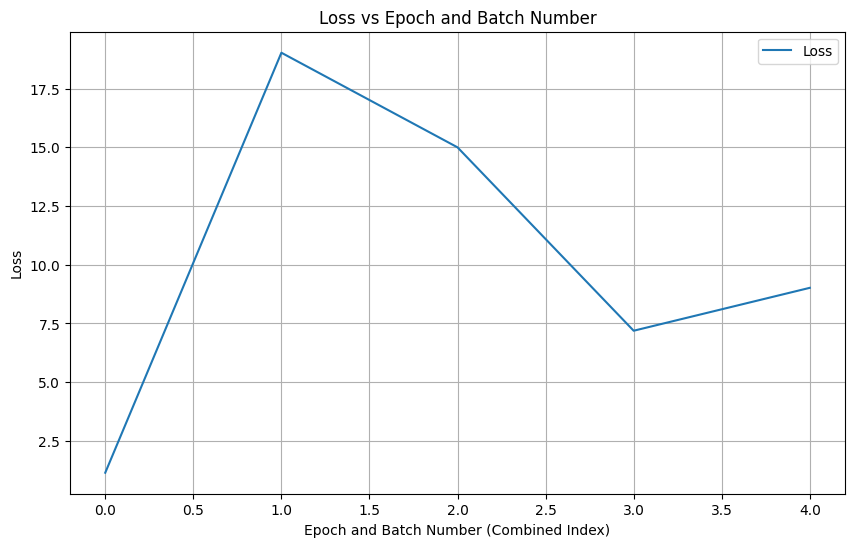

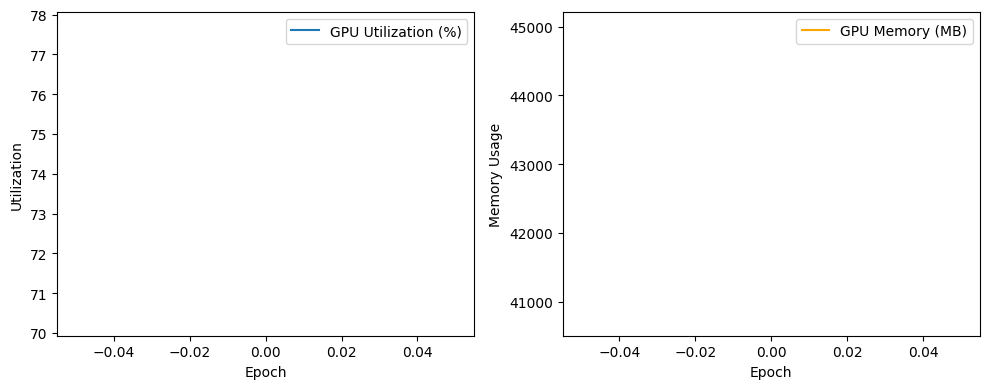

In [5]:

assert training_trial_batch.sizes["time"] >= 3

print(f"Training batch time dimensions: {training_trial_batch.sizes['time']}")

task_config_dict =  dataclasses.asdict(task_config)
# task_config_dict.pop('input_duration')

print("Starting training")

train_graphcast(training_trial_batch, params, task_config_dict, epochs=1)

print("Finished training")

# can add evaluation and comparison code here after testing everything for a few timesteps


In [6]:
losses_file = xr.open_dataset('/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/graphcast/local_files/loss_before_mean_preserving.nc')
losses_file

<xarray.Dataset> Size: 261kB
Dimensions:                  (time: 1, batch: 1, lat: 181, lon: 360)
Dimensions without coordinates: time, batch, lat, lon
Data variables:
    10m_u_component_of_wind  (time, batch, lat, lon) float32 261kB ...

In [7]:
losses_file

<xarray.Dataset> Size: 261kB
Dimensions:                  (time: 1, batch: 1, lat: 181, lon: 360)
Dimensions without coordinates: time, batch, lat, lon
Data variables:
    10m_u_component_of_wind  (time, batch, lat, lon) float32 261kB ...

In [8]:
losses_file['time']

<xarray.DataArray 'time' (time: 1)> Size: 8B
array([0])
Dimensions without coordinates: time